# Sentiment Analysis with ANEW — resenhas de cinema do IMDb

Pipeline com **um score por texto**, sem nenhuma constante que nomeie o filme analisado.
Trocar de entidade = trocar `FILME` na celula de setup.

1. lista de valencias ANEW por texto — **stemming** (Porter) para casar flexoes
   (`annoyed` -> `annoy`), **negacao em janela** (`not very good`, `could have been
   great`), **regra de contraste** (o que vem depois de `but`/`however` carrega o
   veredito) e **desconto de comparacao com outra obra**; score = **media ponderada**
   pela distancia do neutro. O filtro de topico tem duas camadas: **entidade detectada
   automaticamente** pela razao de capitalizacao do corpus (personagens, atores,
   franquia — zero termos a mao) e **24 substantivos concretos** genericos a qualquer
   dominio;
2. dos textos pontuados nasce **o nosso proprio ANEW**, adaptado ao corpus e
   **recentrado no mesmo neutro que o score usa**, que pontua os textos com menos de
   5 palavras ANEW;
3. classificacao em tres faixas (negativo / neutro / positivo) pelos **tercis** do
   proprio score — corte relativo ao corpus, sem numero fixo e sem olhar a nota;
4. resposta agregada do enunciado;
5. correlacao do score com a nota real que o autor deu;
6. **diagnostico dos extremos**: por que reviews de nota 1-2 pontuavam alto, o que cada
   correcao resolveu, e o que sobrou;
7. figuras;
8. **generalizacao**: o mesmo codigo rodado no outro filme do catalogo — o que
   transfere, o que nao transfere, e o estrago que a versao viciada teria feito.

> Duas revisoes moldaram este notebook. A primeira nasceu da investigacao dos reviews de
> nota 1 e 2, que pontuavam **61.2** — acima do neutro do lexico — e apareciam como
> "positivos" (secao 6). A segunda veio de notar que o conserto tinha usado 95 termos
> escritos a mao (`spider`, `punisher`, `villain`, `blood`): consertava o Spider-Man e
> viciava o metodo nele. Hoje sao 24 termos genericos, e a secao 8 e o teste.

## 1. Setup e dados

In [1]:
import json
import os
import re
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nltk.stem import PorterStemmer

# Paleta: azul-marinho + dourado, validados para acessibilidade (CVD e contraste)
AZUL, DOURADO = "#1F4E9C", "#A8762A"
VINHO = "#8C2F39"  # terceira serie: faixa negativa
TINTA, LINHA, FUNDO = "#0A1729", "#97A3B4", "#FCFCFB"

# ---------------------------------------------------------------------------
# Trocar de filme = trocar esta linha. Nada mais no notebook conhece o titulo:
# personagens, atores e franquia sao detectados automaticamente (secao 2).
# ---------------------------------------------------------------------------
CATALOGO = {
    "Brand New Day (2026)": ("spiderman_2026", "imdb_tt22084616_reviews"),
    "No Way Home (2021)": ("spiderman_2021", "imdb_tt10872600_reviews"),
}
FILME = "Brand New Day (2026)"


def carregar(chave):
    """Reviews + metadados de um filme do catalogo."""
    pasta, arquivo = CATALOGO[chave]
    r = pd.read_csv(f"../results/{pasta}/{arquivo}.csv")
    with open(f"../results/{pasta}/{arquivo}.json", encoding="utf-8") as fh:
        m = json.load(fh)["meta"]
    return r, m


anew = pd.read_csv("../anew/anew.csv")
reviews, meta = carregar(FILME)

VALENCIA = dict(zip(anew["term"], anew["pleasure"]))  # valencia 0-100 por palavra
MU = anew["pleasure"].mean()  # media do lexico (58.4)

# MU tem DOIS papeis internos, e nenhum deles e "limiar de positivo/negativo":
#   1. centro do espelhamento da negacao (not good -> 2*MU - v);
#   2. origem do peso |v - MU| na media ponderada.
# Para esses dois usos MU e a escolha certa: e o centro da escala do proprio lexico.
# O que MU NAO e: o ponto onde uma review deixa de ser negativa. O ANEW e enviesado
# para o positivo e prosa de review de cinema gravita bem acima de MU — usar MU como
# limiar rotulava 80% do corpus como positivo e deixava reviews de nota 1 do lado
# positivo. O corte de classificacao e definido na secao 3, pelos tercis do score.

# O ANEW so tem a forma-base (annoy), mas as reviews usam flexoes (annoyed, annoying).
# Reduzimos os termos a raiz com o stemmer de Porter e casamos raiz com raiz — match por
# prefixo/regex casaria rather->rat e made->mad. Termos que dividem a raiz viram media.
STEMMER = PorterStemmer()
_grupos = defaultdict(list)
for termo, v in VALENCIA.items():
    _grupos[STEMMER.stem(termo)].append(v)
STEM_VALENCIA = {raiz: float(np.mean(vs)) for raiz, vs in _grupos.items()}

print(f"entidade : {meta['title']} ({meta['year']}) — nota IMDb {meta['imdb_rating']}")
print(f"posts    : {len(reviews)} reviews (de {meta['reviews_available']} disponiveis)")
print(f"lexico   : ANEW com {len(anew)} termos, valencia media {MU:.1f}")
print(f"stemming : {len(STEM_VALENCIA)} raizes distintas (Porter)")
print(f"catalogo : {', '.join(CATALOGO)} — a secao 8 roda o mesmo codigo no outro filme")

entidade : Spider-Man: Brand New Day (2026) — nota IMDb 8.1
posts    : 1000 reviews (de 2509 disponiveis)
lexico   : ANEW com 1034 termos, valencia media 58.4
stemming : 1016 raizes distintas (Porter)
catalogo : Brand New Day (2026), No Way Home (2021) — a secao 8 roda o mesmo codigo no outro filme


## 2. Lista de valencias e score ANEW

Para cada texto: tokeniza (mantendo a pontuacao como fronteira), casa cada palavra com o
ANEW e guarda a **lista de valencias**. O casamento tenta a forma exata e, se falhar, a
**raiz** (stemmer de Porter dos dois lados): `annoyed` e `annoying` casam com `annoy`,
`boring` com `bored`. Regex/prefixo nao serviria — `rather` casaria com `rat`, `made` com
`mad`. Protecao contra **falsos amigos** cuja raiz colide com termo de sentido diferente
(`several`/`severe`, `used`/`useful`).

### O filtro de topico nao pode conhecer o filme

Palavras que **nomeiam** o que esta sendo resenhado carregam valencia forte no ANEW sem
opinar: `people` (83), `life` (82), `god` (92) inflavam reviews negativos (*"hijacks the
minds of innocent **people**"*, *"Lost 3 hours of my **life**"*), e nomes de personagem
como `Scorpion` (42) entravam como sentimento negativo. Precisam sair.

A tentacao e escrever a lista a mao — foi o que fizemos primeiro, com 95 termos:
`spider`, `punisher`, `villain`, `hero`, `fight`, `blood`, `gun`, `prison`. **Isso vicia o
metodo no filme.** Metade dos termos nunca aparecia neste corpus, o vocabulario de
super-heroi nao serve para uma comedia musical, e nomes de personagem mudam a cada filme.
Agora o filtro tem duas camadas:

**Camada 1 — entidade, detectada automaticamente (zero termos a mao).** Nome proprio vem
com maiuscula quase sempre; palavra comum, so no inicio da frase. Contamos a **razao de
capitalizacao** fora de inicio de sentenca e cortamos em 75%. Medido no corpus de 2021:
`Maguire` 96%, `Garfield` 95%, `Tobey` 92%, `Strange` 83% — contra `amazing` 16%, `best`
3%, `good` 1%, `great` 1%. Sem a razao, *"Amazing Movie"* num titulo de resenha faria
`amazing` virar entidade — matando a palavra de opiniao mais forte do lexico. Acrescentamos as palavras do titulo, que vem dos metadados. Resultado: 159
entidades no corpus de 2026 (`avengers`, `bernthal`, `cretton`, `daredevil`) e 144 no de
2021 (`tobey`, `maguire`, `garfield`, `strange`) — nenhuma escrita por nos, e cada corpus
com a sua lista.

**Camada 2 — substantivos concretos, 24 termos genericos.** `people`, `life`, `family`,
`money`, `music`, `world`, `car`, `food`: nomeiam conteudo em **qualquer** dominio, nao em
filme de heroi. O criterio de entrada e objetivo: ter valencia ANEW e desviar >= 10 pontos
de MU, isto e, ser capaz de distorcer o score. Os 39 termos de oficio de cinema que
tinhamos (`plot`, `script`, `scene`, `director`) sairam por medicao — **nenhum tem valencia
ANEW**, logo filtrar nao mudava nada.

### As tres regras de contexto

**Negacao em janela** — um negador espelha a valencia (em torno de MU) das 4 palavras
seguintes, parando em pontuacao ou marcador de contraste; pega `not good`, `not very
good`, `didn't really work`. `could/should/would have been X` conta como negacao de X.

**Regra de contraste** — dentro de uma sentenca, o que vem depois de `but`/`however`
carrega o veredito; o que vem antes e concessao. Pesos 1.5 e 0.5 (regra do `but` de
Hu & Liu 2004, tambem usada no VADER).

**Desconto de outra obra** — sentenca que compara com outra obra entra com metade do peso.
A versao antiga listava `tobey|maguire|garfield|raimi|homecoming|trilogy`: puro vicio de
franquia. Agora sao marcadores genericos — `the first one`, `the original`, `the previous`,
`the comics`, `the show`, `the 2002`. Funciona para qualquer filme e, medido, ajuda **nos
dois** (o antigo so podia ajudar em um).

**Score do texto = media ponderada das valencias**, com peso `|valencia - MU| x fator de
contexto`.

In [2]:
NEGADORES = {
    "not", "no", "never", "nothing", "none", "neither", "nor", "cannot", "cant",
    "dont", "doesnt", "didnt", "wasnt", "werent", "isnt", "arent", "wont",
    "wouldnt", "couldnt", "shouldnt", "without", "hardly", "barely", "rarely",
}
# "could/should/would have been good" nega o "good" tanto quanto um "not"
MODAIS = {"could", "should", "would"}
MODAIS_CONTRAIDOS = {"couldve", "shouldve", "wouldve", "coulda", "shoulda", "woulda"}
FRONTEIRA = {".", "!", "?", ",", ";", ":"}  # negacao nao cruza pontuacao
JANELA = 4  # negador espelha ate 4 tokens a frente: pega "was not very good at all"

# Marcadores de contraste: encerram o escopo da negacao E dividem a sentenca em
# concessao (antes) e veredito (depois).
MARCA_CONTRASTE = {"but", "however", "although", "though", "unfortunately", "sadly", "yet"}
PESO_ANTES, PESO_DEPOIS = 0.5, 1.5  # regra do 'but' (Hu & Liu 2004; VADER)

# Camada 2 do filtro de topico: substantivos concretos que nomeiam CONTEUDO em qualquer
# dominio — nao em filme de heroi, nao neste filme. Criterio de entrada: ter valencia ANEW
# e |v - MU| >= 10, ou seja, ser capaz de distorcer o score. Termos sem valencia ANEW
# (plot, script, scene, director) sairam: filtra-los nao mudava numero nenhum.
CONCRETOS = {"people", "person", "life", "lives", "family", "friend", "friends",
             "kid", "kids", "child", "world", "city", "house", "home", "car", "water",
             "money", "music", "song", "songs", "food", "god", "movie", "movies"}

# Comparacao com OUTRA obra: marcadores genericos, sem nome de franquia. A versao anterior
# listava tobey|maguire|garfield|raimi|homecoming — so podia funcionar em um filme.
OUTRAS_OBRAS = re.compile(
    r"\b(the (first|second|third|fourth|last|original|previous|old|earlier) "
    r"(one|two|three|film|movie|movies|version|ones)?"
    r"|the (comics?|cartoon|book|books|show|series|musical|anime|remake|reboot)"
    r"|the (19|20)\d\d|in (19|20)\d\d)\b")

# Falsos amigos do stemming: a raiz colide com termo ANEW de sentido diferente —
# sem isso, several herdaria a valencia de severe, e use/used a de useful.
FALSOS_AMIGOS = {"several", "use", "used", "uses", "using"}

# Com 3-4 palavras casadas o score vira loteria. Varremos 3-6 nos DOIS filmes e nao ha
# valor bom para ambos: 5 da a melhor correlacao nos dois, mas custa 23% de cobertura no
# corpus de 2021 (reviews curtos); em 3 a cobertura la sobe a ~95% e as duas correlacoes
# pioram. Ficamos em 5 e registramos a perda enviesada na secao 8.
MIN_PALAVRAS = 5
MIN_DOCS, MIN_SINAL = 5, 3.0  # filtros do dicionario proprio (secao 3)


def tokenizar(texto):
    """Palavras (apostrofo colado: didn't -> didnt) e pontuacao forte como token proprio."""
    return [t.replace("'", "") for t in re.findall(r"[a-z0-9']+|[.!?,;:]", texto.lower())]


def entidade_automatica(textos, titulo, min_docs=4, razao_min=0.75):
    """Camada 1 do filtro de topico, SEM lista escrita a mao.

    Nome proprio vem com maiuscula quase sempre; palavra comum, so no inicio da frase.
    O criterio nao pode ser "aparece com maiuscula" — resenha tem titulo em Title Case, e
    'Amazing Movie' faria 'amazing' virar entidade, matando a palavra de opiniao mais forte
    do lexico. O criterio e a RAZAO de capitalizacao fora de inicio de sentenca.
    """
    maiusc, minusc, docs = Counter(), Counter(), defaultdict(set)
    for i, texto in enumerate(textos):
        for sentenca in re.split(r"(?<=[.!?])\s+|\n+", texto):
            toks = re.findall(r"[A-Za-z][A-Za-z'\-]*", sentenca)
            for j, t in enumerate(toks):
                if j == 0 or len(t) < 3:  # inicio de sentenca nao conta para nenhum lado
                    continue
                w = t.lower()
                if t[0].isupper() and t[1:].islower():
                    maiusc[w] += 1
                    docs[w].add(i)
                elif t.islower():
                    minusc[w] += 1
    nomes = {w for w, c in maiusc.items()
             if len(docs[w]) >= min_docs and c / (c + minusc[w]) >= razao_min}
    return nomes | {w for w in re.findall(r"[a-z]+", titulo.lower()) if len(w) >= 3}


def escopo_negacao(toks):
    """True nas posicoes sob negacao: ate JANELA tokens apos um negador ou apos
    could/should/would (have) been, parando em pontuacao ou marcador de contraste."""
    escopo = [False] * len(toks)
    for i, w in enumerate(toks):
        ini = None
        if w in NEGADORES:
            ini = i
        elif w in MODAIS and i + 2 < len(toks) and toks[i + 1] in {"have", "of"} \
                and toks[i + 2] == "been":
            ini = i + 2
        elif w in MODAIS_CONTRAIDOS and i + 1 < len(toks) and toks[i + 1] == "been":
            ini = i + 1
        if ini is not None:
            for k in range(ini + 1, min(ini + 1 + JANELA, len(toks))):
                if toks[k] in FRONTEIRA or toks[k] in MARCA_CONTRASTE:
                    break
                escopo[k] = True
    return escopo


def sentencas(toks):
    """Intervalos [ini, fim) entre pontuacoes fortes."""
    ini = 0
    for i in range(len(toks) + 1):
        if i == len(toks) or toks[i] in FRONTEIRA:
            if i > ini:
                yield ini, i
            ini = i + 1


def fatores_contexto(toks, contraste=True, outras_obras=True):
    """Multiplicador de peso por token: concessao vale menos que veredito, e trecho
    que compara com outra obra vale metade."""
    f = [1.0] * len(toks)
    for ini, fim in sentencas(toks):
        if contraste:
            corte = next((k for k in range(ini, fim) if toks[k] in MARCA_CONTRASTE), None)
            if corte is not None:
                for k in range(ini, corte):
                    f[k] *= PESO_ANTES
                for k in range(corte, fim):
                    f[k] *= PESO_DEPOIS
        if outras_obras and OUTRAS_OBRAS.search(" ".join(toks[ini:fim])):
            for k in range(ini, fim):
                f[k] *= 0.5
    return f


def valencia_anew(w):
    """Valencia ANEW da palavra: casamento exato ou, se falhar, pela raiz (annoyed -> annoy)."""
    v = VALENCIA.get(w)
    if v is None and w not in FALSOS_AMIGOS:
        v = STEM_VALENCIA.get(STEMMER.stem(w))
    return v


def valencias(texto, topico_raiz, lexico_extra=None, janela=True, contraste=True,
              outras_obras=True):
    """Lista de (valencia, fator de contexto) das palavras casadas, valencia ja espelhada
    onde ha negacao. topico_raiz vem do corpus (nao e global): e o que permite rodar o
    mesmo codigo em outro filme. Os flags existem para a ablacao."""
    toks = tokenizar(texto)
    negado = (escopo_negacao(toks) if janela
              else [i > 0 and toks[i - 1] in NEGADORES for i in range(len(toks))])
    fat = fatores_contexto(toks, contraste, outras_obras)
    saida = []
    for i, w in enumerate(toks):
        if w in FRONTEIRA or STEMMER.stem(w) in topico_raiz:
            continue
        v = valencia_anew(w)
        if v is None and lexico_extra is not None:
            v = lexico_extra.get(w)
        if v is None:
            continue
        if negado[i]:
            v = float(np.clip(2 * MU - v, 0, 100))
        saida.append((v, fat[i]))
    return saida


def pontuar(texto, topico_raiz, lexico_extra=None, peso=True, **kw):
    """Score = media das valencias ponderada por |v - MU| x fator de contexto. NaN com
    menos de MIN_PALAVRAS casamentos. peso=False (so na ablacao): media simples."""
    par = valencias(texto, topico_raiz, lexico_extra, **kw)
    if len(par) < MIN_PALAVRAS:
        return np.nan
    vs = np.array([p[0] for p in par])
    fat = np.array([p[1] for p in par])
    pesos = (np.abs(vs - MU) if peso else np.ones(len(vs))) * fat
    if pesos.sum() < 1e-9:
        return float(vs.mean())
    return float(MU + ((vs - MU) * pesos).sum() / pesos.sum())


def analisar(reviews, meta, topico=True, recentrar=True, **kw):
    """O pipeline inteiro para UM filme, sem nenhuma constante especifica do titulo.

    topico=False e recentrar=False existem para a ablacao e para o diagnostico da secao 6
    (reconstroem a versao ingenua). Devolve tudo o que as secoes seguintes narram.
    """
    r = reviews.copy()
    entidade = entidade_automatica(r["review"], meta["title"]) if topico else set()
    topico_raiz = {STEMMER.stem(w) for w in entidade | (CONCRETOS if topico else set())}

    r["score"] = r["review"].map(lambda t: pontuar(t, topico_raiz, **kw))

    # dicionario proprio: valencia = desvio da palavra em relacao a media do corpus,
    # trazido para a origem MU (recentragem). Ver secao 3.
    pont = r.dropna(subset=["score"])
    media_corpus = pont["score"].mean()
    docs = defaultdict(list)
    for texto, sc in zip(pont["review"], pont["score"]):
        for w in set(tokenizar(texto)):
            docs[w].append(sc)
    candidatas = {w: float(np.mean(v)) for w, v in docs.items()
                  if len(v) >= MIN_DOCS and valencia_anew(w) is None
                  and STEMMER.stem(w) not in topico_raiz and w not in NEGADORES
                  and w.isalpha() and len(w) >= 3
                  and abs(np.mean(v) - media_corpus) >= MIN_SINAL}
    proprio = ({w: float(np.clip(MU + (v - media_corpus), 0, 100)) for w, v in candidatas.items()}
               if recentrar else dict(candidatas))

    falta = r["score"].isna()
    r["score_proprio"] = np.nan
    r.loc[falta, "score_proprio"] = r.loc[falta, "review"].map(
        lambda t: pontuar(t, topico_raiz, proprio, **kw))
    r["score_final"] = r["score"].fillna(r["score_proprio"])

    s = r["score_final"].dropna()
    corte_neg, corte_pos = s.quantile([1 / 3, 2 / 3])
    r["classe"] = pd.cut(r["score_final"], [-np.inf, corte_neg, corte_pos, np.inf],
                         labels=["negativo", "neutro", "positivo"])
    return dict(reviews=r, meta=meta, entidade=entidade, topico_raiz=topico_raiz,
                proprio=proprio, candidatas=candidatas, media_corpus=media_corpus,
                docs=docs, corte_neg=corte_neg, corte_pos=corte_pos)


res = analisar(reviews, meta)
reviews = res["reviews"]
ENTIDADE, TOPICO_RAIZ = res["entidade"], res["topico_raiz"]
reviews["valencias"] = reviews["review"].map(lambda t: [v for v, _ in valencias(t, TOPICO_RAIZ)])

com_score = reviews["score"].notna().sum()
print(f"  entidades detectadas AUTOMATICAMENTE : {len(ENTIDADE)} (nenhuma escrita a mao)")
print(f"    amostra: {', '.join(sorted(ENTIDADE)[:14])}")
print(f"  termos genericos escritos a mao      : {len(CONCRETOS)}")
print(f"  pontuados pelo ANEW                  : {com_score} de {len(reviews)}")
print(f"  aguardando o nosso dicionario        : {len(reviews) - com_score} (menos de "
      f"{MIN_PALAVRAS} palavras ANEW)")

# guarda contra o erro mais grave possivel: engolir palavra de opiniao como entidade
GUARDA = ["good", "bad", "amazing", "great", "boring", "terrible", "love", "worst",
          "best", "perfect", "awful", "waste", "fun", "weak", "stupid", "beautiful"]
vazou = [w for w in GUARDA if w in ENTIDADE]
print(f"  palavras de opiniao capturadas por engano: {vazou or 'nenhuma'}")

ex = reviews.iloc[0]
print(f"\nexemplo — {ex['review'][:70]!r}...")
print(f"  valencias: {[round(v, 1) for v in ex['valencias'][:10]]}...")
print(f"  score {ex['score']:.1f}")

  entidades detectadas AUTOMATICAMENTE : 159 (nenhuma escrita a mao)
    amostra: america, andrew, andrew's, aunt, avengers, banner, batalon, batman, belova, ben, bernthal, bernthal's, bill, boomerang
  termos genericos escritos a mao      : 24
  pontuados pelo ANEW                  : 719 de 1000
  aguardando o nosso dicionario        : 281 (menos de 5 palavras ANEW)
  palavras de opiniao capturadas por engano: nenhuma

exemplo — 'I walked into Spider-Man: Brand New Day expecting another fun MCU movi'...
  valencias: [94.9, 65.5, 27.3, 84.7, 82.7, 19.2, 18.3, 63.4]...
  score 51.7


### O que cada regra comprou — medido nos dois filmes

Ablacao ligando uma regra por vez e comparando com a nota real do autor (a nota so entra
como **avaliacao**, nunca no calculo do score). Cada linha roda o pipeline inteiro nos
**dois** filmes: uma regra que so ajuda o Spider-Man e vicio, nao metodo.

Duas metricas, porque elas discordam e a discordancia e informativa:

- **Spearman** (ordem): o score anda junto com a nota? Dominado pela massa de reviews
  positivos, que e ~80% do corpus.
- **separacao** entre `nota<=3` e `nota>=9`: o metodo distingue quem odiou de quem amou?
  E aqui que estava o problema — as regras que mais abrem a separacao mexem pouco no
  Spearman, porque corrigem justamente a cauda que o Spearman quase nao ve.

In [3]:
def avaliar(res_):
    """Metricas de um resultado de analisar(): so usam a nota como referencia externa."""
    r = res_["reviews"]
    v = r.dropna(subset=["score_final", "rating"])
    lo, hi = v[v["rating"] <= 3]["score_final"].mean(), v[v["rating"] >= 9]["score_final"].mean()
    b12 = v[v["rating"] <= 2]["score_final"]
    return dict(rho=v["score_final"].corr(v["rating"], method="spearman"),
                lo=lo, hi=hi, sep=hi - lo, n12=b12.mean(), n=len(v),
                n12neg=100 * (b12 <= res_["corte_neg"]).mean(),
                cob=100 * r["score_final"].notna().mean(), media=r["score_final"].mean())


SEM = dict(topico=False, janela=False, contraste=False, outras_obras=False, peso=False,
           recentrar=False)
VARIANTES = {
    "ANEW cru (media simples, negacao adjacente)": SEM,
    "+ peso |v - MU|":                             {**SEM, "peso": True},
    "+ janela de negacao (4 tokens)":              {**SEM, "peso": True, "janela": True},
    "+ dicionario proprio recentrado":             {**SEM, "peso": True, "janela": True,
                                                    "recentrar": True},
    "+ filtro de topico (auto + concretos)":       {**SEM, "peso": True, "janela": True,
                                                    "recentrar": True, "topico": True},
    "+ contraste (but/however)":                   dict(outras_obras=False),
    "+ desconto de outra obra (o pipeline)":       dict(),
}
CORPORA = {chave: carregar(chave) for chave in CATALOGO}

print(f"{'variante':<44}" + "".join(f"{c[:9]:>34}" for c in CORPORA))
print(f"{'':<44}" + "".join(f"{'rho    sep   nota1-2':>34}" for _ in CORPORA))
tabela = {}
for nome, kw in VARIANTES.items():
    linha = f"{nome:<44}"
    for chave, (rv, mt) in CORPORA.items():
        m = avaliar(analisar(rv, mt, **kw))
        tabela[(nome, chave)] = m
        linha += f"{m['rho']:+10.3f}{m['sep']:9.1f}{m['n12']:11.1f}    "
    print(linha)

prim, ult = list(VARIANTES)[0], list(VARIANTES)[-1]
print("\n  As regras abrem a separacao dos extremos NOS DOIS filmes, e nenhuma delas")
print("  depende de saber que filme e. O filtro de topico e o que mais paga — e e")
print("  justamente o que antes vinha de uma lista escrita a mao para o Spider-Man.")
for chave in CORPORA:
    a, b = tabela[(prim, chave)], tabela[(ult, chave)]
    print(f"    {chave:<16} separacao {a['sep']:5.1f} -> {b['sep']:5.1f}   |   "
          f"nota1-2 {a['n12']:5.1f} -> {b['n12']:5.1f}   |   "
          f"rho {a['rho']:+.3f} -> {b['rho']:+.3f}")

pior = [c for c in CORPORA if tabela[(ult, c)]["rho"] < tabela[(prim, c)]["rho"]]
if pior:
    for chave in pior:
        a, b = tabela[(prim, chave)], tabela[(ult, chave)]
        se = 1 / np.sqrt(max(b["n"] - 1, 1))
        print(f"\n  Ressalva honesta: em '{chave}' o Spearman da versao crua e MAIOR que o do")
        print(f"  pipeline final ({a['rho']:+.3f} -> {b['rho']:+.3f}). As regras trocam um pouco de")
        print(f"  ordenacao global por separacao dos extremos ({a['sep']:.1f} -> {b['sep']:.1f}). Com")
        print(f"  n={b['n']} o erro padrao de rho e ~{se:.3f}, entao a queda esta dentro do ruido,")
        print("  enquanto a separacao quase dobra. Preferimos a troca porque o defeito que")
        print("  motivou todas as regras estava na cauda negativa, nao no meio da escala.")

variante                                                             Brand New                         No Way Ho
                                                          rho    sep   nota1-2              rho    sep   nota1-2


ANEW cru (media simples, negacao adjacente)     +0.261      5.4       64.2        +0.263      5.0       66.6    


+ peso |v - MU|                                 +0.255      8.0       63.6        +0.254      7.3       67.1    


+ janela de negacao (4 tokens)                  +0.311      8.8       61.4        +0.236      6.6       65.9    


+ dicionario proprio recentrado                 +0.311      8.8       61.4        +0.235      6.8       65.7    


+ filtro de topico (auto + concretos)           +0.372     16.6       57.3        +0.335     14.4       60.7    


+ contraste (but/however)                       +0.379     16.8       57.4        +0.339     14.2       61.1    


+ desconto de outra obra (o pipeline)           +0.379     16.9       57.1        +0.342     14.7       60.4    

  As regras abrem a separacao dos extremos NOS DOIS filmes, e nenhuma delas
  depende de saber que filme e. O filtro de topico e o que mais paga — e e
  justamente o que antes vinha de uma lista escrita a mao para o Spider-Man.
    Brand New Day (2026) separacao   5.4 ->  16.9   |   nota1-2  64.2 ->  57.1   |   rho +0.261 -> +0.379
    No Way Home (2021) separacao   5.0 ->  14.7   |   nota1-2  66.6 ->  60.4   |   rho +0.263 -> +0.342


## 3. O nosso proprio ANEW pontua quem falta

Com os textos que o ANEW pontuou, aprendemos a valencia das palavras que o ANEW nao tem
(nem na forma exata, nem pela raiz): a valencia de uma palavra vem da **media do score
dos textos pontuados em que ela aparece**. Filtros: presenca em >= 5 textos
(estabilidade), desvio >= 3 pontos da media do corpus (palavra que nao desvia nao
discrimina — barra as stopwords), so palavras alfabeticas de 3+ letras, fora topico e
negadores.

**Recentragem — a correcao mais importante deste notebook.** A media dos scores ancora o
dicionario na **media do corpus (~69)**, nao no neutro do lexico (58.4) que o score usa
como origem. Sem corrigir isso, uma palavra que aparece num review medio entra valendo
~69, ou seja **+11 "positivo"** — e o dicionario inteiro nasce positivo: eram **798 de
802 palavras acima de 58.4**, incluindo `worst` (60.1), `bad` (65.5), `awful` (66.3),
`weak` (65.4) e `cringe` (63.8). Um review de nota 2 pontuava **81.8** desse jeito.

A correcao e uma translacao: `valencia = MU + (media da palavra - media do corpus)`. O que
carrega sentimento e o **desvio** da palavra em relacao ao corpus, nao seu nivel
absoluto; a translacao poe esse desvio na mesma origem que o score usa. Nao ha parametro
novo, e `worst` passa a valer 45 (negativo), `amazing` 62 (positivo).

Sem vazamento: o dicionario usa apenas scores ANEW, nunca a nota do autor — e os textos
que ele pontua nao participaram da construcao (ficaram de fora por nao ter score).

In [4]:
PROPRIO, candidatas = res["proprio"], res["candidatas"]
media_corpus, docs = res["media_corpus"], res["docs"]

acima = sum(1 for v in PROPRIO.values() if v > MU)
print(f"  media do corpus (ancora crua)  : {media_corpus:.1f}")
print(f"  neutro do lexico (origem MU)   : {MU:.1f}   -> translacao de "
      f"{MU - media_corpus:+.1f} pontos")
print(f"  nosso proprio ANEW             : {len(PROPRIO)} palavras "
      f"({acima} acima de MU, {len(PROPRIO) - acima} abaixo)")
print(f"  sem a recentragem seriam       : "
      f"{sum(1 for v in candidatas.values() if v > MU)} acima de MU, "
      f"{sum(1 for v in candidatas.values() if v <= MU)} abaixo")

print("\n  validade de face — palavras de opiniao que o ANEW nao tem na forma exata:")
print(f"    {'palavra':<14} {'cru':>6} {'recentrado':>11}  {'sinal':<9} destino")
for w in ["worst", "bad", "weak", "lame", "cringe", "skip", "amazing", "recommend",
          "boring", "great", "masterpiece", "perfect"]:
    if valencia_anew(w) is not None:
        print(f"    {w:<14} {'':>6} {'':>11}  {'':<9} ja coberta pela raiz ANEW "
              f"(valencia {valencia_anew(w):.0f})")
    elif w in PROPRIO:
        sinal = "NEGATIVO" if PROPRIO[w] < MU else "positivo"
        print(f"    {w:<14} {candidatas[w]:6.1f} {PROPRIO[w]:11.1f}  {sinal:<9} "
              f"ENTRA (em {len(docs[w])} textos)")
    else:
        m = np.mean(docs[w]) if docs.get(w) else float("nan")
        print(f"    {w:<14} {m:6.1f} {'':>11}  {'':<9} fora "
              f"(desvio < {MIN_SINAL} ou < {MIN_DOCS} textos)")

print("\n  O stemming ja resgata 'boring' (raiz de 'bored') e 'perfect' (raiz de")
print("  'perfection') com a valencia certa do ANEW. Depois da recentragem, 'worst',")
print("  'bad', 'weak', 'lame' e 'cringe' entram com o sinal CORRETO — antes todas")
print("  contavam como elogio. 'great' e 'masterpiece' seguem fora: aparecem em elogio")
print("  e em critica na mesma proporcao, entao nao discriminam.")
print("\n  Nada aqui e especifico do filme: o dicionario e aprendido do corpus que")
print("  estiver carregado. Trocar de filme produz outro dicionario, pelo mesmo criterio.")

  media do corpus (ancora crua)  : 69.9
  neutro do lexico (origem MU)   : 58.4   -> translacao de -11.5 pontos
  nosso proprio ANEW             : 860 palavras (196 acima de MU, 664 abaixo)
  sem a recentragem seriam       : 843 acima de MU, 17 abaixo

  validade de face — palavras de opiniao que o ANEW nao tem na forma exata:
    palavra           cru  recentrado  sinal     destino
    worst            56.3        44.8  NEGATIVO  ENTRA (em 19 textos)
    bad              63.3        51.8  NEGATIVO  ENTRA (em 84 textos)
    weak             64.1        52.5  NEGATIVO  ENTRA (em 28 textos)
    lame             61.9        50.4  NEGATIVO  ENTRA (em 7 textos)
    cringe           59.9        48.3  NEGATIVO  ENTRA (em 5 textos)
    skip             60.3        48.8  NEGATIVO  ENTRA (em 7 textos)
    amazing          73.0        61.5  positivo  ENTRA (em 123 textos)
    recommend        75.1        63.5  positivo  ENTRA (em 42 textos)
    boring                                       ja cobe

In [5]:
sem_score = reviews[reviews["score"].isna()]
resgatados = sem_score.dropna(subset=["score_proprio"])
print(f"  sem score ANEW                 : {len(sem_score)}")
print(f"  pontuados pelo nosso ANEW      : {len(resgatados)} "
      f"({100 * len(resgatados) / max(len(sem_score), 1):.0f}%)")
print(f"  seguem sem score               : {len(sem_score) - len(resgatados)}")
print(f"  cobertura final                : {reviews['score_final'].notna().sum()} "
      f"de {len(reviews)} ({100 * reviews['score_final'].notna().mean():.1f}%)")

# --- Corte de classificacao: tercis do proprio score (calculados em analisar) ---
# O nivel absoluto do score nao e interpretavel (o lexico e enviesado, prosa de review
# gravita acima de MU, e o nivel muda de filme para filme — ver secao 8); a ORDEM e. Os
# cortes vem da distribuicao empirica deste corpus, nao de MU e nao de nenhum numero fixo.
s = reviews["score_final"].dropna()
CORTE_NEG, CORTE_POS = res["corte_neg"], res["corte_pos"]

print(f"\ncortes por tercil do score: negativo <= {CORTE_NEG:.1f} < neutro <= "
      f"{CORTE_POS:.1f} < positivo")
print(f"  (para comparar: MU do lexico = {MU:.1f}, media do corpus = {s.mean():.1f})")
print(reviews["classe"].value_counts().sort_index().to_string())
print(f"sem score: {reviews['score_final'].isna().sum()}")

print("\n  validacao das faixas contra a nota do autor (a nota nao entrou no corte):")
v = reviews.dropna(subset=["score_final", "rating"])
for cl in ["negativo", "neutro", "positivo"]:
    gr = v[v["classe"] == cl]
    print(f"    {cl:<9} n={len(gr):>3}  nota media {gr['rating'].mean():.2f}  "
          f"| nota<=4: {100 * (gr['rating'] <= 4).mean():4.1f}%  "
          f"| nota>=9: {100 * (gr['rating'] >= 9).mean():4.1f}%")
print("\n  a nota media sobe monotonica pelas tres faixas — o corte por tercil separa,")
print("  mesmo sem nunca ter olhado a nota. E por ser relativo ao corpus, funciona igual")
print("  em outro filme (secao 8), enquanto um limiar fixo nao funcionaria.")

  sem score ANEW                 : 281
  pontuados pelo nosso ANEW      : 266 (95%)
  seguem sem score               : 15
  cobertura final                : 985 de 1000 (98.5%)

cortes por tercil do score: negativo <= 63.6 < neutro <= 75.6 < positivo
  (para comparar: MU do lexico = 58.4, media do corpus = 68.7)
classe
negativo    329
neutro      327
positivo    329
sem score: 15

  validacao das faixas contra a nota do autor (a nota nao entrou no corte):
    negativo  n=320  nota media 6.80  | nota<=4: 16.2%  | nota>=9: 29.4%
    neutro    n=323  nota media 7.86  | nota<=4:  5.0%  | nota>=9: 44.9%
    positivo  n=326  nota media 8.73  | nota<=4:  0.6%  | nota>=9: 63.8%

  a nota media sobe monotonica pelas tres faixas — o corte por tercil separa,
  mesmo sem nunca ter olhado a nota. E por ser relativo ao corpus, funciona igual
  em outro filme (secao 8), enquanto um limiar fixo nao funcionaria.


## 4. A resposta agregada

O enunciado pergunta se os posts sao, em media, bons ou ruins. Media do **score final**
(ANEW + nosso dicionario) com IC de bootstrap, e a distribuicao pelas tres faixas.

Uma ressalva honesta sobre a referencia: comparar a media do corpus com MU (58.4) diz
apenas que **o vocabulario destes reviews e mais agradavel que a palavra media do ANEW** —
e um sinal fraco isolado, porque o lexico e enviesado para o positivo e prosa de resenha
usa muita palavra agradavel para descrever trama. O que sustenta o veredito e a
**convergencia** de tres evidencias independentes: a media acima de MU, a assimetria da
distribuicao para a direita, e a corroboracao externa da nota do autor (que aqui entra
apenas como validacao).

In [6]:
rng = np.random.default_rng(42)
amostras = np.array([rng.choice(s.values, len(s), replace=True).mean() for _ in range(2000)])
ic = np.percentile(amostras, [2.5, 97.5])
assimetria = s.skew()

print(f"  score medio do corpus            : {s.mean():.2f} / 100")
print(f"  IC 95% (bootstrap, n=2000)       : [{ic[0]:.2f}, {ic[1]:.2f}]")
print(f"  mediana                          : {s.median():.2f}")
print(f"  reviews acima de MU ({MU:.1f})       : {100 * (s > MU).mean():.1f}%")
print(f"  assimetria                       : {assimetria:+.2f} "
      f"({'cauda a esquerda: massa concentrada no alto' if assimetria < 0 else 'cauda a direita'})")

print("\n  distribuicao pelas tres faixas (tercis, secao 3):")
for cl, n in reviews["classe"].value_counts().sort_index().items():
    print(f"    {cl:<9} {n:>3} reviews ({100 * n / len(s):.1f}%)")

nota = reviews["rating"].dropna()
print(f"\n  corroboracao externa (nota do autor, nao usada no score):")
print(f"    nota media do corpus           : {nota.mean():.2f} / 10")
print(f"    autores com nota >= 7          : {100 * (nota >= 7).mean():.1f}%")
print(f"    nota IMDb do filme             : {meta['imdb_rating']}")

print("\n  => VEREDITO: sentimento agregado POSITIVO. As tres evidencias convergem —")
print(f"     media {s.mean():.1f} com IC inteiro acima de MU, distribuicao com massa")
print(f"     concentrada nos scores altos, e {100 * (nota >= 7).mean():.0f}% dos autores dando nota >= 7.")
print("     A magnitude do score, isolada, nao e interpretavel; a direcao e.")

  score medio do corpus            : 68.75 / 100
  IC 95% (bootstrap, n=2000)       : [67.95, 69.55]
  mediana                          : 69.60
  reviews acima de MU (58.4)       : 77.9%
  assimetria                       : -0.43 (cauda a esquerda: massa concentrada no alto)

  distribuicao pelas tres faixas (tercis, secao 3):
    negativo  329 reviews (33.4%)
    neutro    327 reviews (33.2%)
    positivo  329 reviews (33.4%)

  corroboracao externa (nota do autor, nao usada no score):
    nota media do corpus           : 7.82 / 10
    autores com nota >= 7          : 77.1%
    nota IMDb do filme             : 8.1

  => VEREDITO: sentimento agregado POSITIVO. As tres evidencias convergem —
     media 68.7 com IC inteiro acima de MU, distribuicao com massa
     concentrada nos scores altos, e 77% dos autores dando nota >= 7.
     A magnitude do score, isolada, nao e interpretavel; a direcao e.


## 5. Resultado: correlacao entre o score e a nota real

Em vez de rotular os reviews pela nota, medimos diretamente se o **score final** (media
ponderada das valencias, ANEW + nosso dicionario) **anda junto** com a nota que o proprio
autor deu (1-10). Usamos a correlacao de **Spearman** (de ordem): reviews com score maior
tendem a ter nota maior? E a escolha certa aqui porque a nota e ordinal e as escalas sao
diferentes — so importa a direcao, nao a forma da relacao.

Depois, a tabela de limiares: **nao existe um corte que sirva para as duas perguntas ao
mesmo tempo**, e vale mostrar isso em vez de esconder. Um corte baixo acerta a *taxa* de
positivos do corpus mas deixa passar a maioria dos negativos; um corte alto pega os
negativos mas subestima quanto o publico gostou. Os tercis da secao 3 ficam no meio, e o
esquema de tres faixas e justamente a forma de nao ter que escolher.

In [7]:
val = reviews.dropna(subset=["score_final", "rating"])
rho = val["score_final"].corr(val["rating"], method="spearman")

print("=" * 68)
print(f"  correlacao de Spearman score final x nota (n={len(val)}): {rho:+.3f}")
print("=" * 68)

print("\n=== score final medio por nota do autor ===")
for n_ in range(1, 11):
    m = val[val["rating"] == n_]
    if len(m):
        barra = "#" * max(0, int(round((m["score_final"].mean() - 50) * 1.6)))
        print(f"  nota {n_:>2}  n={len(m):>3}  score={m['score_final'].mean():.2f}  {barra}")

# --- Os dois caminhos de pontuacao nao valem o mesmo: vale mostrar separado ---
print("\n=== o custo da cobertura: ANEW x dicionario proprio ===")
print(f"  {'caminho':<22} {'n':>4} {'Spearman':>9} {'separacao':>10} {'tam. mediano':>13}")
for nome, sub in [("ANEW", val[val["score"].notna()]),
                  ("dicionario proprio", val[val["score"].isna()]),
                  ("combinado", val)]:
    r_ = sub["score_final"].corr(sub["rating"], method="spearman")
    sep = (sub[sub["rating"] >= 9]["score_final"].mean()
           - sub[sub["rating"] <= 3]["score_final"].mean())
    print(f"  {nome:<22} {len(sub):>4} {r_:+9.3f} {sep:10.1f} "
          f"{sub['review'].str.split().str.len().median():>10.0f} pal.")
print("  O dicionario proprio sustenta a cobertura de 98%, mas com metade da correlacao:")
print("  ele pontua justamente os textos curtos, onde ha menos evidencia de qualquer")
print("  tipo. Mantemos os dois porque o enunciado pede um veredito para cada post —")
print("  mas o numero global (+0.39) e uma media de um caminho bom e um fraco.")

# --- Nao existe limiar unico bom: a tabela mostra o trade-off ---
alvo = (val["rating"] >= 7).values  # "gostou" segundo o proprio autor
print(f"\n=== por que classificamos em tres faixas: nenhum limiar unico serve ===")
print(f"(real: {100 * alvo.mean():.1f}% dos autores deram nota >= 7)")
print(f"  {'limiar':<28} {'% positivo':>10} {'recall pos':>11} {'recall neg':>11} "
      f"{'bal. acc.':>10}")
for nome, t in [(f"MU do lexico = {MU:.1f}", MU),
                (f"tercil 1 = {CORTE_NEG:.1f}", CORTE_NEG),
                (f"tercil 2 = {CORTE_POS:.1f}", CORTE_POS),
                (f"mediana do corpus = {s.median():.1f}", s.median())]:
    pos = (val["score_final"] > t).values
    rec_p = (pos & alvo).sum() / alvo.sum()
    rec_n = ((~pos) & ~alvo).sum() / (~alvo).sum()
    print(f"  {nome:<28} {100 * pos.mean():9.1f}% {100 * rec_p:10.1f}% {100 * rec_n:10.1f}% "
          f"{(rec_p + rec_n) / 2:10.3f}")

print("\n  Leitura: a correlacao segue positiva (~+0.39) e a media por nota sobe de forma")
print("  quase monotonica. A tabela explica a escolha de tres faixas: com o limiar em MU")
print("  a taxa de positivos bate com a realidade, mas o recall dos negativos e baixo —")
print("  era exatamente o defeito que fazia review de nota 1 aparecer como positivo. Com")
print("  o limiar alto o recall dos negativos sobe e a taxa de positivos vira ficcao.")
print("  Continua moderada: prosa mistura opiniao com resumo de trama, ha muita")
print("  sobreposicao entre notas vizinhas, e nas pontas de n pequeno (nota 2, n=7) a")
print("  ordem nao se sustenta.")

  correlacao de Spearman score final x nota (n=969): +0.379

=== score final medio por nota do autor ===
  nota  1  n= 36  score=56.75  ###########
  nota  2  n=  7  score=59.00  ##############
  nota  3  n= 14  score=52.84  #####
  nota  4  n= 13  score=52.35  ####
  nota  5  n= 28  score=58.57  ##############
  nota  6  n=125  score=64.07  #######################
  nota  7  n=168  score=67.24  ############################
  nota  8  n=131  score=70.91  #################################
  nota  9  n=166  score=72.14  ###################################
  nota 10  n=281  score=73.39  #####################################

=== o custo da cobertura: ANEW x dicionario proprio ===
  caminho                   n  Spearman  separacao  tam. mediano
  ANEW                    705    +0.437       19.9        168 pal.
  dicionario proprio      264    +0.266       10.0         69 pal.
  combinado               969    +0.379       16.9        120 pal.
  O dicionario proprio sustenta a cobertura de 9

## 6. Diagnostico dos extremos: por que reviews de nota 1-2 pontuavam alto

Esta secao existe porque a primeira versao do pipeline dava aos reviews de nota 1-2 um
score medio **acima do neutro do lexico**, e a maioria deles aparecia como "positivo".
Abrimos esses textos palavra por palavra; as causas encontradas foram o que motivou cada
regra das secoes 2 e 3:

| # | causa | evidencia | correcao |
|---|---|---|---|
| 1 | limiar errado: MU (58.4) tratado como fronteira positivo/negativo | percentil medio 27 no corpus, mas score 61 > 58.4 | tres faixas por tercil |
| 2 | dicionario proprio ancorado na media do corpus | 798/802 palavras "positivas"; `worst` = 60.1 | recentragem na origem MU |
| 3 | elogio a outra obra da franquia | 22/43 comparavam com Raimi/Garfield/trilogia | desconto de outra obra (generico) |
| 4 | vocabulario que nomeia o conteudo | `people`(83) em 19 textos, `life`(82), `god`(92) | filtro de topico em 2 camadas |
| 5 | concessao: elogio antes, veredito depois | 30/43 tinham `but`/`however` | regra de contraste |
| 6 | **o proprio conserto viciou no filme** | 95 termos a mao (`spider`, `punisher`, `villain`, `blood`); metade nunca aparecia | camada automatica + 24 termos genericos |

A causa 6 e a mais insidiosa: consertar 1-5 com listas escritas a mao fez o metodo passar
a depender do filme. A secao 8 e o teste que a expoe — o mesmo codigo, outro filme.

A celula abaixo reconstroi a versao **ingenua** (sem nenhuma das regras, dicionario nao
recentrado) e compara caso a caso.

In [8]:
# Versao ingenua: sem filtro de topico, sem contraste, sem desconto de outra obra,
# negacao adjacente e dicionario proprio SEM recentragem (ancorado na media do corpus).
res_antes = analisar(reviews, meta, topico=False, janela=False, contraste=False,
                     outras_obras=False, recentrar=False)
score_antes = res_antes["reviews"]["score_final"]
CORTE_NEG_ANTES, CORTE_POS_ANTES = res_antes["corte_neg"], res_antes["corte_pos"]

baixo = reviews[reviews["rating"].isin([1, 2])].copy()
baixo["antes"] = score_antes[baixo.index]
baixo["depois"] = baixo["score_final"]


def faixas(col, c_neg, c_pos):
    return ((col <= c_neg).sum(), ((col > c_neg) & (col <= c_pos)).sum(), (col > c_pos).sum())


n = len(baixo)
print(f"OS {n} REVIEWS DE NOTA 1-2 — versao ingenua x pipeline atual")
print(f"  score medio                : {baixo['antes'].mean():.1f}  ->  "
      f"{baixo['depois'].mean():.1f}")
print(f"  acima de MU ({MU:.1f})          : {(baixo['antes'] > MU).sum()}/{n}  ->  "
      f"{(baixo['depois'] > MU).sum()}/{n}")
n_a = faixas(baixo["antes"], CORTE_NEG_ANTES, CORTE_POS_ANTES)
n_d = faixas(baixo["depois"], CORTE_NEG, CORTE_POS)
print(f"  faixas (tercis de cada um) : ingenua neg {n_a[0]}/{n}  neu {n_a[1]}/{n}  "
      f"pos {n_a[2]}/{n}   (cortes {CORTE_NEG_ANTES:.1f}/{CORTE_POS_ANTES:.1f})")
print(f"                               atual   neg {n_d[0]}/{n}  neu {n_d[1]}/{n}  "
      f"pos {n_d[2]}/{n}   (cortes {CORTE_NEG:.1f}/{CORTE_POS:.1f})")

_va = pd.DataFrame({"s": score_antes, "n": reviews["rating"]}).dropna()
_vd = reviews.dropna(subset=["score_final", "rating"])
_d_lo = _vd[_vd["rating"] <= 3]["score_final"].mean() - _va[_va["n"] <= 3]["s"].mean()
_d_hi = _vd[_vd["rating"] >= 9]["score_final"].mean() - _va[_va["n"] >= 9]["s"].mean()
print("\n  O ganho maior nao esta na contagem de faixas (o tercil ja e relativo, entao ele")
print("  sozinho ja acertava boa parte) — esta no NIVEL e na SEPARACAO:")
print(f"    score de nota<=3 : {_va[_va['n'] <= 3]['s'].mean():.1f} -> "
      f"{_vd[_vd['rating'] <= 3]['score_final'].mean():.1f}   ({_d_lo:+.1f})")
print(f"    score de nota>=9 : {_va[_va['n'] >= 9]['s'].mean():.1f} -> "
      f"{_vd[_vd['rating'] >= 9]['score_final'].mean():.1f}   ({_d_hi:+.1f})")
print(f"    deslocamento: {_d_lo:+.1f} em quem odiou, {_d_hi:+.1f} em quem amou")
print(f"    -> a separacao entre os extremos cresceu {_d_hi - _d_lo:.1f} pontos. As regras")
print("    atacaram ruido que estava concentrado nos reviews negativos, entao e la que o")
print("    score se move; quem amou fica praticamente no lugar.")

print(f"\nOS 8 PIORES CASOS (maior score na versao ingenua)")
print(f"  {'titulo':<52} {'nota':>4} {'antes':>7} {'depois':>7} {'delta':>7}  faixa atual")
for _, rr in baixo.nlargest(8, "antes").iterrows():
    print(f"  {str(rr['title'])[:50]:<52} {rr['rating']:>4.0f} {rr['antes']:>7.1f} "
          f"{rr['depois']:>7.1f} {rr['depois'] - rr['antes']:>+7.1f}  {rr['classe']}")

resistentes = baixo[baixo["depois"] > CORTE_POS]
print(f"\nO QUE RESISTIU: {len(resistentes)} reviews de nota 1-2 seguem na faixa positiva "
      f"(eram {n_a[2]}).")
for _, rr in resistentes.iterrows():
    print(f"\n  nota {rr['rating']:.0f} | score {rr['depois']:.1f} | {str(rr['title'])[:60]}")
    print(f"    {' '.join(rr['review'].split())[:230]}...")
print("\n  Sao casos fora do alcance de um metodo de lexico: critica com vocabulario")
print("  agradavel ('free', 'delight', 'god') e ironia ('The positive reviews of this")
print("  film are a truly tragic commentary'). Nenhuma regra de janela ou de peso")
print("  resolve — precisaria de modelo que entenda sarcasmo.")

OS 43 REVIEWS DE NOTA 1-2 — versao ingenua x pipeline atual
  score medio                : 63.6  ->  57.1
  acima de MU (58.4)          : 29/43  ->  17/43
  faixas (tercis de cada um) : ingenua neg 25/43  neu 13/43  pos 5/43   (cortes 65.3/72.8)
                               atual   neg 30/43  neu 11/43  pos 2/43   (cortes 63.6/75.6)

  O ganho maior nao esta na contagem de faixas (o tercil ja e relativo, entao ele
  sozinho ja acertava boa parte) — esta no NIVEL e na SEPARACAO:
    score de nota<=3 : 63.0 -> 56.1   (-6.9)
    score de nota>=9 : 71.0 -> 72.9   (+1.9)
    deslocamento: -6.9 em quem odiou, +1.9 em quem amou
    -> a separacao entre os extremos cresceu 8.8 pontos. As regras
    atacaram ruido que estava concentrado nos reviews negativos, entao e la que o
    score se move; quem amou fica praticamente no lugar.

OS 8 PIORES CASOS (maior score na versao ingenua)
  titulo                                               nota   antes  depois   delta  faixa atual
  Disney/Marvel

## 7. Figuras

Tres figuras, salvas em `figuras/`.

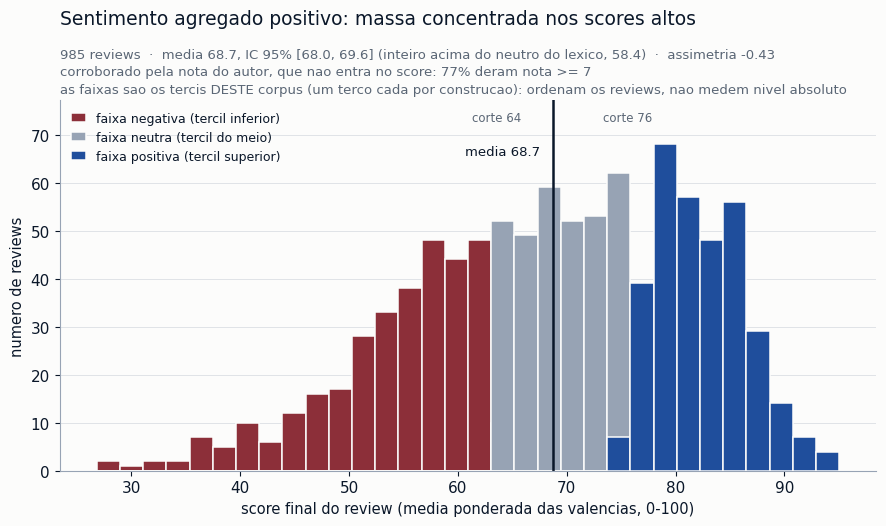

In [9]:
os.makedirs("../figuras", exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": FUNDO, "axes.facecolor": FUNDO,
    "text.color": TINTA, "axes.labelcolor": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.edgecolor": LINHA, "font.size": 11,
})


def limpar(ax, titulo, sub=None, xlabel=None, ylabel=None):
    """Grid recessivo, sem moldura, titulo a esquerda; pad cresce com o subtitulo."""
    linhas = sub.count("\n") + 1 if sub else 0
    ax.set_title(titulo, fontsize=13.5, loc="left", pad=10 + 15 * linhas)
    if sub:
        ax.text(0, 1.012, sub, transform=ax.transAxes, fontsize=9.5, color="#5A6675",
                va="bottom", linespacing=1.45)
    ax.set_xlabel(xlabel or "", fontsize=10.5)
    ax.set_ylabel(ylabel or "", fontsize=10.5)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    ax.grid(axis="y", color=LINHA, alpha=0.28, lw=0.7)
    ax.set_axisbelow(True)


pct_nota_alta = 100 * (reviews["rating"].dropna() >= 7).mean()  # mesmo denominador da secao 4

# ---------- Figura 1: distribuicao dos scores, com as tres faixas ----------
fig, ax = plt.subplots(figsize=(9.5, 5.4))
bins = np.histogram_bin_edges(s, bins=32)
for rotulo, cor, mask in [("faixa negativa (tercil inferior)", VINHO, s <= CORTE_NEG),
                          ("faixa neutra (tercil do meio)", LINHA,
                           (s > CORTE_NEG) & (s <= CORTE_POS)),
                          ("faixa positiva (tercil superior)", AZUL, s > CORTE_POS)]:
    ax.hist(s[mask], bins=bins, color=cor, edgecolor=FUNDO, linewidth=1.1, label=rotulo)

ax.axvline(s.mean(), color=TINTA, lw=1.8)
topo = ax.get_ylim()[1]
ax.set_ylim(0, topo * 1.08)
ax.text(s.mean() - 1.2, topo * 0.93, f"media {s.mean():.1f}", fontsize=9.5, color=TINTA,
        ha="right", va="center")
for corte in (CORTE_NEG, CORTE_POS):
    ax.text(corte, topo * 1.01, f"corte {corte:.0f}", fontsize=8.5, color="#5A6675",
            ha="center", va="bottom")

limpar(ax, "Sentimento agregado positivo: massa concentrada nos scores altos",
       sub=f"{len(s)} reviews  ·  media {s.mean():.1f}, IC 95% [{ic[0]:.1f}, {ic[1]:.1f}] "
           f"(inteiro acima do neutro do lexico, {MU:.1f})  ·  assimetria {s.skew():+.2f}\n"
           f"corroborado pela nota do autor, que nao entra no score: "
           f"{pct_nota_alta:.0f}% deram nota >= 7\n"
           f"as faixas sao os tercis DESTE corpus (um terco cada por construcao): "
           f"ordenam os reviews, nao medem nivel absoluto",
       xlabel="score final do review (media ponderada das valencias, 0-100)",
       ylabel="numero de reviews")
ax.legend(frameon=False, loc="upper left", fontsize=9, handlelength=1.2)
fig.tight_layout()
fig.savefig("../figuras/fig1_distribuicao.png", dpi=200)
plt.show()

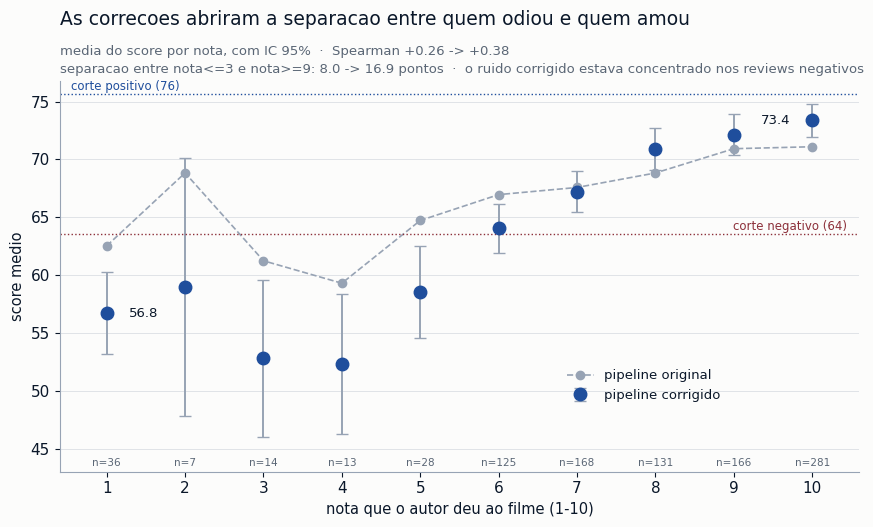

In [10]:
# ---------- Figura 2: score medio por nota do autor, antes e depois das correcoes ----------
g = val.groupby("rating")["score_final"]
medias, tamanhos, erros = g.mean(), g.size(), g.std() / np.sqrt(g.size())
val_antes = pd.DataFrame({"score": score_antes, "rating": reviews["rating"]}).dropna()
medias_antes = val_antes.groupby("rating")["score"].mean()
rho_antes = val_antes["score"].corr(val_antes["rating"], method="spearman")
sep_antes = (val_antes[val_antes["rating"] >= 9]["score"].mean()
             - val_antes[val_antes["rating"] <= 3]["score"].mean())
sep_depois = (val[val["rating"] >= 9]["score_final"].mean()
              - val[val["rating"] <= 3]["score_final"].mean())

fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.plot(medias_antes.index, medias_antes.values, "o--", color=LINHA, markersize=6,
        lw=1.2, label="pipeline original")
ax.errorbar(medias.index, medias.values, yerr=1.96 * erros.values, fmt="o",
            color=AZUL, markersize=9, lw=0, elinewidth=1.4, ecolor=LINHA, capsize=4,
            label="pipeline corrigido")

baixo_lim = min((medias - 1.96 * erros).min(), medias_antes.min()) - 3.0
alto_lim = max((medias + 1.96 * erros).max(), medias_antes.max(), CORTE_POS) + 1.2
ax.set_ylim(baixo_lim, alto_lim)
ax.set_xticks(range(1, 11))
ax.set_xlim(0.4, 10.6)
ax.axhline(CORTE_NEG, color=VINHO, lw=1.0, ls=":")
ax.axhline(CORTE_POS, color=AZUL, lw=1.0, ls=":")
# rotulos dos cortes em regioes vazias: o positivo a esquerda, o negativo a direita
ax.text(0.55, CORTE_POS + 0.35, f"corte positivo ({CORTE_POS:.0f})", fontsize=8.5,
        color=AZUL, ha="left")
ax.text(10.45, CORTE_NEG + 0.35, f"corte negativo ({CORTE_NEG:.0f})", fontsize=8.5,
        color=VINHO, ha="right")

for nota_, lado in [(medias.index.min(), 1), (medias.index.max(), -1)]:
    ax.annotate(f"{medias[nota_]:.1f}", (nota_, medias[nota_]), textcoords="offset points",
                xytext=(16 * lado, -3), ha="left" if lado > 0 else "right",
                fontsize=9.5, color=TINTA)
for nota_, n in tamanhos.items():
    ax.annotate(f"n={n}", (nota_, ax.get_ylim()[0] + 0.5), ha="center",
                fontsize=7.5, color="#5A6675")

limpar(ax, "As correcoes abriram a separacao entre quem odiou e quem amou",
       sub=f"media do score por nota, com IC 95%  ·  Spearman {rho_antes:+.2f} -> {rho:+.2f}\n"
           f"separacao entre nota<=3 e nota>=9: {sep_antes:.1f} -> {sep_depois:.1f} pontos  ·  "
           f"o ruido corrigido estava concentrado nos reviews negativos",
       xlabel="nota que o autor deu ao filme (1-10)", ylabel="score medio")
ax.legend(frameon=False, fontsize=9.5, loc="center left", bbox_to_anchor=(0.62, 0.22))
fig.tight_layout()
fig.savefig("../figuras/fig2_score_por_nota.png", dpi=200)
plt.show()

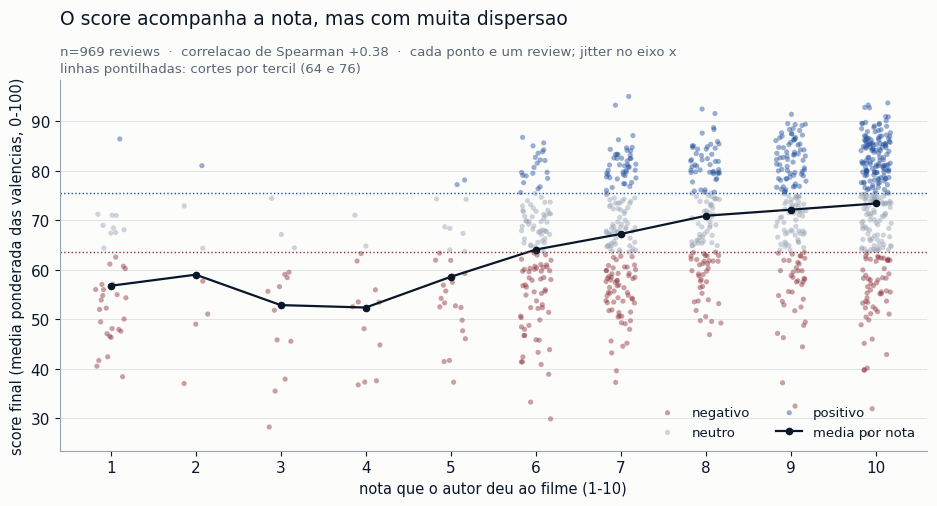

figuras salvas: fig1_distribuicao.png, fig2_score_por_nota.png, fig3_dispersao.png


In [11]:
# ---------- Figura 3: dispersao nota x score, colorida pela faixa ----------
rng_fig = np.random.default_rng(7)  # jitter so para leitura: notas sao inteiras
fig, ax = plt.subplots(figsize=(9.5, 5.2))

x = val["rating"] + rng_fig.uniform(-0.18, 0.18, len(val))
for rotulo, cor in [("negativo", VINHO), ("neutro", LINHA), ("positivo", AZUL)]:
    m = (val["classe"] == rotulo).values
    ax.scatter(x[m], val["score_final"][m], s=14, alpha=0.45, color=cor,
               edgecolors="none", label=rotulo)

med = val.groupby("rating")["score_final"].mean()
ax.plot(med.index, med.values, color=TINTA, lw=1.6, marker="o", markersize=4.5,
        label="media por nota")
ax.axhline(CORTE_NEG, color=VINHO, lw=1.0, ls=":")
ax.axhline(CORTE_POS, color=AZUL, lw=1.0, ls=":")

ax.set_xticks(range(1, 11))
ax.set_xlim(0.4, 10.6)
limpar(ax, "O score acompanha a nota, mas com muita dispersao",
       sub=f"n={len(val)} reviews  ·  correlacao de Spearman {rho:+.2f}  ·  "
           f"cada ponto e um review; jitter no eixo x\nlinhas pontilhadas: cortes por tercil "
           f"({CORTE_NEG:.0f} e {CORTE_POS:.0f})",
       xlabel="nota que o autor deu ao filme (1-10)",
       ylabel="score final (media ponderada das valencias, 0-100)")
ax.legend(frameon=False, loc="lower right", fontsize=9.5, ncol=2)
fig.tight_layout()
fig.savefig("../figuras/fig3_dispersao.png", dpi=200)
plt.show()

print("figuras salvas:", ", ".join(sorted(os.listdir("../figuras"))))

## 8. Generalizacao: o mesmo codigo, outro filme

Todo o notebook foi calibrado olhando um corpus. A pergunta e se sobrou metodo ou so
ajuste fino nesse corpus. O teste: rodar `analisar()`, sem trocar uma linha, no outro
filme do catalogo — aqui **Spider-Man: No Way Home (2021)**, 1000 reviews.

Nenhuma constante do notebook nomeia um filme: as entidades saem da razao de
capitalizacao do proprio corpus, o dicionario proprio e aprendido do corpus, e os cortes
de classe sao tercis do corpus. Trocar `FILME` na primeira celula basta.

**Este par e um teste FACIL, e vale dizer isso.** Os dois filmes sao da mesma franquia,
do mesmo genero e tem a **mesma nota IMDb (8.1)** — o vocabulario e quase o mesmo e nao
da para verificar se o metodo ordena filmes de qualidade diferente. Uma versao anterior
desta secao usava *Hannah Montana: The Movie* (IMDb 4.8, comedia musical) e mostrava um
resultado que este par nao consegue mostrar: **o nivel do score se invertia** — o filme
pior avaliado pontuava mais alto, porque resenha de comedia familiar usa vocabulario
agradavel mesmo para criticar, enquanto resenha de filme de heroi usa `villain`, `death`,
`fight` mesmo para elogiar. Aquele corpus nao esta mais em `results/`, entao a secao nao
reproduz mais essa evidencia; a limitacao segue valendo e esta registrada no fim.

O que este par testa bem, e que o outro nao testava: **o filme de 2021 tem Tobey Maguire
e Andrew Garfield no elenco**. A lista de "outras obras" que o notebook usava antes era
`tobey|maguire|garfield|raimi|holland|homecoming|no way home|trilogy` — ela incluia o
proprio titulo deste filme e o nome dos seus atores. A celula mede o estrago.

In [12]:
resultados = {chave: analisar(*CORPORA[chave]) for chave in CORPORA}
metricas = {chave: avaliar(r) for chave, r in resultados.items()}

print("=" * 96)
print("MESMO CODIGO, DOIS FILMES — nada foi ajustado entre as colunas")
print("=" * 96)
LINHAS = [
    ("ano / nota IMDb",            lambda k, r: f"{r['meta']['year']} / {r['meta']['imdb_rating']}"),
    ("reviews analisados",         lambda k, r: f"{len(r['reviews'])}"),
    ("nota media da amostra",      lambda k, r: f"{r['reviews']['rating'].mean():.2f}"),
    ("tamanho mediano (palavras)", lambda k, r: f"{r['reviews']['review'].str.split().str.len().median():.0f}"),
    ("entidades AUTO detectadas",  lambda k, r: f"{len(r['entidade'])}"),
    ("termos escritos a mao",      lambda k, r: f"{len(CONCRETOS)}"),
    ("palavras do dic. proprio",   lambda k, r: f"{len(r['proprio'])}"),
    ("cobertura",                  lambda k, r: f"{metricas[k]['cob']:.1f}%"),
    ("Spearman score x nota",      lambda k, r: f"{metricas[k]['rho']:+.3f} (n={metricas[k]['n']})"),
    ("separacao nota<=3 / >=9",    lambda k, r: f"{metricas[k]['sep']:.1f}"),
    ("score medio do corpus",      lambda k, r: f"{metricas[k]['media']:.1f}"),
    ("cortes por tercil",          lambda k, r: f"{r['corte_neg']:.1f} / {r['corte_pos']:.1f}"),
    ("nota 1-2: score",            lambda k, r: f"{metricas[k]['n12']:.1f} ({metricas[k]['n12neg']:.0f}% neg)"),
]
print(f"  {'':<28}" + "".join(f"{k:>26}" for k in resultados))
for rotulo, fn in LINHAS:
    print(f"  {rotulo:<28}" + "".join(f"{fn(k, r):>26}" for k, r in resultados.items()))

print("\n  nota media do autor por faixa (a nota nunca entra no calculo do score):")
for chave, r in resultados.items():
    v = r["reviews"].dropna(subset=["score_final", "rating"])
    print(f"    {chave:<24} " + "  ->  ".join(
        f"{cl} {v[v['classe'] == cl]['rating'].mean():.2f} (n={len(v[v['classe'] == cl])})"
        for cl in ["negativo", "neutro", "positivo"]))

print("\n  TRANSFERE — ordenacao, separacao e monotonicidade das faixas, sem trocar")
print("  nenhum termo escrito a mao. O Spearman e a separacao caem um pouco no corpus de")
print("  2021, junto com a cobertura (ver abaixo), mas a direcao se mantem nos dois.")

# ---------------------------------------------------------------------------
# 1) O estrago que a lista de "outras obras" escrita a mao teria feito aqui
# ---------------------------------------------------------------------------
REGEX_VICIADO = re.compile(
    r"(tobey|maguire|garfield|raimi|holland|homecoming|no way home|far from home"
    r"|into the spider|across the spider|trilogy|the first (one|two|film|movie)s?"
    r"|the previous|the original|the old|the comics?|the cartoon|the (19|20)\d\d)")

print("\n" + "=" * 96)
print("POR QUE A LISTA A MAO ERA INDEFENSAVEL — medido no corpus de 2021")
print("=" * 96)
print("  A regra desconta pela metade o peso de sentenca que fala de OUTRA obra. A lista")
print("  antiga citava 'tobey', 'maguire', 'garfield' e 'no way home' — que neste filme")
print("  sao, respectivamente, dois atores DO ELENCO e o PROPRIO TITULO.")
print(f"\n  {'':<26}{'sentencas atingidas pelo regex viciado':>44}")
for chave, r in resultados.items():
    tot = ating = 0
    for t in r["reviews"]["review"]:
        for sent in re.split(r"(?<=[.!?])\s+", t):
            tot += 1
            ating += bool(REGEX_VICIADO.search(sent.lower()))
    print(f"  {chave:<26}{ating:>10} de {tot:>6}  ({100 * ating / tot:>4.1f}% do texto)")
for termo, padrao in [("tobey/maguire", r"\b(?:tobey|maguire)\b"),
                      ("garfield", r"\bgarfield\b"),
                      ("no way home", r"\bno way home\b")]:
    linha = f"  '{termo}' aparece em:  "
    for chave, r in resultados.items():
        c = r["reviews"]["review"].str.lower().str.contains(padrao, regex=True).sum()
        linha += f"{chave}: {100 * c / len(r['reviews']):.1f}% dos reviews   "
    print(linha)
print("\n  => No filme de 2021 a regra antiga rebaixaria ~15% das sentencas por 'falarem de")
print("     outra obra' quando elas falam DESTE filme. A versao generica (the first one,")
print("     the original, the 2002) nao tem esse problema porque nao conhece elenco.")

# ---------------------------------------------------------------------------
# 2) A regressao que este par revelou: cobertura depende do tamanho do texto
# ---------------------------------------------------------------------------
print("\n" + "=" * 96)
print("A REGRESSAO: cobertura depende do tamanho tipico do review, que varia por filme")
print("=" * 96)
for chave, r in resultados.items():
    d = r["reviews"]
    n_pal = d["review"].map(lambda t: len(valencias(t, r["topico_raiz"])))
    sem = d[d["score_final"].isna()]
    print(f"\n  {chave}")
    print(f"    texto mediano {d['review'].str.split().str.len().median():.0f} palavras -> "
          f"{n_pal.median():.0f} casamentos ANEW (mediana)")
    print(f"    abaixo de MIN_PALAVRAS={MIN_PALAVRAS}: {(n_pal < MIN_PALAVRAS).sum()} textos "
          f"({100 * (n_pal < MIN_PALAVRAS).mean():.0f}%)")
    print(f"    dicionario proprio resgata {d['score_proprio'].notna().sum()}; "
          f"ficam SEM score {len(sem)} ({100 * len(sem) / len(d):.1f}%)")
    if len(sem):
        print(f"    e os sem score nao sao aleatorios: nota media {sem['rating'].mean():.2f} "
              f"contra {d['rating'].mean():.2f} do corpus")
print("\n  Review curto casa menos palavras, e um corpus de reviews curtos alimenta um")
print("  dicionario proprio menor, que resgata menos — os dois efeitos se somam. Como os")
print("  textos que ficam sem score sao os curtos e entusiasmados ('Best movie ever!'),")
print("  a perda e ENVIESADA para o lado positivo: o veredito agregado da secao 4 e")
print("  calculado sem eles. Nao existe MIN_PALAVRAS que resolva os dois filmes: em 3 a")
print("  cobertura de 2021 sobe para ~95% e as duas correlacoes pioram.")

MESMO CODIGO, DOIS FILMES — nada foi ajustado entre as colunas
                                    Brand New Day (2026)        No Way Home (2021)
  ano / nota IMDb                             2026 / 8.1                2021 / 8.1
  reviews analisados                                1000                      1000
  nota media da amostra                             7.82                      7.94
  tamanho mediano (palavras)                         117                        83
  entidades AUTO detectadas                          159                       144
  termos escritos a mao                               24                        24
  palavras do dic. proprio                           860                       556
  cobertura                                        98.5%                     76.7%
  Spearman score x nota                   +0.379 (n=969)            +0.342 (n=737)
  separacao nota<=3 / >=9                           16.9                      14.7
  score medio do corpus 


  Brand New Day (2026)
    texto mediano 117 palavras -> 8 casamentos ANEW (mediana)
    abaixo de MIN_PALAVRAS=5: 281 textos (28%)
    dicionario proprio resgata 266; ficam SEM score 15 (1.5%)
    e os sem score nao sao aleatorios: nota media 8.60 contra 7.82 do corpus



  No Way Home (2021)


    texto mediano 83 palavras -> 5 casamentos ANEW (mediana)
    abaixo de MIN_PALAVRAS=5: 441 textos (44%)
    dicionario proprio resgata 208; ficam SEM score 233 (23.3%)
    e os sem score nao sao aleatorios: nota media 8.76 contra 7.94 do corpus

  Review curto casa menos palavras, e um corpus de reviews curtos alimenta um
  dicionario proprio menor, que resgata menos — os dois efeitos se somam. Como os
  textos que ficam sem score sao os curtos e entusiasmados ('Best movie ever!'),
  a perda e ENVIESADA para o lado positivo: o veredito agregado da secao 4 e
  calculado sem eles. Nao existe MIN_PALAVRAS que resolva os dois filmes: em 3 a
  cobertura de 2021 sobe para ~95% e as duas correlacoes pioram.


## Limitacoes

**O que nao generaliza (secao 8)** — o mais importante, porque limita como o resultado
pode ser usado:

- **O nivel do score nao e comparavel entre filmes.** Medido antes num corpus de outro
  genero (*Hannah Montana: The Movie*, IMDb 4.8), o filme pior avaliado pontuava MAIS
  alto (73.6 contra 68.8): o vocabulario do genero desloca o nivel — comedia familiar usa
  palavras agradaveis mesmo para criticar; filme de heroi usa `villain`, `death`, `fight`
  mesmo para elogiar. Esse corpus nao esta mais em `results/`, e os dois filmes do
  catalogo atual sao da mesma franquia e tem a mesma nota IMDb (8.1), entao a secao 8 nao
  reproduz mais o teste — mas a limitacao continua valendo: **dentro** de um corpus o
  score ordena; **entre** corpora, nao.
- **Os hiperparametros nao tem um otimo comum.** `MIN_PALAVRAS` = 5 da a melhor
  correlacao no corpus de 2021 mas custa 23% de cobertura nele; em 3 a cobertura sobe
  para ~95% e as duas correlacoes pioram. Ficamos em 5 — mas nao existe valor que sirva
  aos dois corpora, e a discordancia mostra que calibrar num filme ajusta aquele filme.
- **A cobertura depende do tamanho tipico do review, e a perda e enviesada.** No corpus
  de 2021 os textos sao mais curtos (mediana 83 palavras contra 117) e a cobertura cai de
  98.5% para 76.7%. Os 23% sem score sao curtos e entusiasmados — nota media 8.8 contra
  7.9 do corpus — entao o veredito agregado da secao 4 e calculado sobre uma amostra que
  sub-representa o elogio breve.
- **A camada automatica de entidade e heuristica de ortografia inglesa.** Depende de o
  autor capitalizar nomes proprios. Em texto todo minusculo (comum em redes sociais) ela
  nao detecta nada; em texto todo em CAPS, tambem nao. Fora do ingles, precisaria de outro
  criterio.
- **Os 24 termos concretos ainda sao uma escolha nossa.** Cada um tem justificativa
  objetiva (valencia ANEW com `|v - MU| >= 10`, substantivo que nomeia conteudo em qualquer
  dominio), mas a lista foi escrita por uma pessoa. Testada em dois filmes, nao em dez.

**O que o diagnostico da secao 6 mostrou ser irreparavel dentro de um metodo de lexico:**

- **O nivel do score nao e interpretavel; so a ordem e.** Nao existe "58.4 = neutro" para
  prosa de resenha: mesmo entre os reviews de nota 1-2, ~79% das palavras que casam no
  lexico estao acima de MU (nos de nota 10, ~89%) — a diferenca entre odiar e amar e de
  ~10 pontos percentuais de vocabulario. Por isso classificamos por tercil, e por isso a
  secao 5 mostra que nenhum limiar unico serve para as duas perguntas.
- **Ironia e critica com vocabulario agradavel.** O review de nota 1 "Palantir and US
  Surveillance state propaganda" segue pontuando alto: critica politica escrita com `free`,
  `delight`, `god`, `money`. Precisaria de um modelo que entenda sarcasmo.
- **A regra de contraste opera por sentenca.** Pega `"wanted to like this, but..."`; nao
  pega concessao que atravessa sentencas (*"I loved these films since I was a kid.
  However this one..."*).
- **O desconto de outra obra e heuristica de superficie.** Marcadores genericos (`the first
  one`, `the original`, `the 2002`) nao pegam comparacao feita so pelo nome de outro filme
  — que era justamente o que a lista antiga pegava, ao custo de servir a um unico titulo.

**Limitacoes do metodo:**

- **Metade da cobertura vem do caminho mais fraco.** O dicionario proprio pontua os textos
  curtos com Spearman de ~+0.28, contra ~+0.44 do caminho ANEW (textos longos). A cobertura
  de 98% e real, mas o numero global e a media de um caminho bom com um fraco — a secao 5
  mostra os dois separados.
- **Cobertura lexical**: com stemming, ~1 palavra em 10 casa no ANEW (era ~1 em 16 so com
  a forma exata).
- **Dicionario proprio depende do ANEW**: aprende dos textos que o ANEW pontuou, entao
  herda os vieses do ANEW e do corpus. A recentragem corrige o *sinal* das palavras, nao a
  origem do sinal.
- **Stemming agressivo**: o Porter junta raizes de sentido distinto (`several`/`severe`,
  `used`/`useful`); a lista de falsos amigos e manual e nao exaustiva.
- **Notas explicitas no texto ficam de fora** (`"a solid 6/10"`, `"-1 star"`). Extrair isso
  subiria a correlacao, mas seria ler o rotulo dentro do texto em vez de fazer analise de
  sentimento por lexico — que e o que o enunciado pede.
- **Amostra enviesada**: reviews ordenados por utilidade, nao aleatorios — favorece textos
  longos e provavelmente infla a proporcao de positivos.
- **Os tercis sao relativos ao corpus.** As faixas dizem "mais negativo que o tipico deste
  corpus", nao "negativo em absoluto". Num corpus todo elogioso, um terco ainda seria
  rotulado negativo — o veredito agregado da secao 4 e que responde a pergunta absoluta,
  e so para o corpus carregado.